In [1]:
import os
import sys
import contextlib
import io
import warnings

warnings.filterwarnings(
    "ignore",
    message=".*Geometry is in a geographic CRS.*",
    category=UserWarning,
)

ROOT = os.path.abspath(".")
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)
sys.path.insert(0, os.path.join(ROOT, "py_scripts"))

import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

from parse_adjacency import parse_adjacency, load_adjacency
from parse_county_data import parse_county_data, load_county_data
from min_coverage import solve_min_coverage
from equitable_placement import solve_equitable

STATE_FIPS_TO_NAME = {
    "01": "Alabama", "02": "Alaska", "04": "Arizona", "05": "Arkansas", "06": "California",
    "08": "Colorado", "09": "Connecticut", "10": "Delaware", "11": "District of Columbia",
    "12": "Florida", "13": "Georgia", "15": "Hawaii", "16": "Idaho", "17": "Illinois",
    "18": "Indiana", "19": "Iowa", "20": "Kansas", "21": "Kentucky", "22": "Louisiana",
    "23": "Maine", "24": "Maryland", "25": "Massachusetts", "26": "Michigan",
    "27": "Minnesota", "28": "Mississippi", "29": "Missouri", "30": "Montana",
    "31": "Nebraska", "32": "Nevada", "33": "New Hampshire", "34": "New Jersey",
    "35": "New Mexico", "36": "New York", "37": "North Carolina", "38": "North Dakota",
    "39": "Ohio", "40": "Oklahoma", "41": "Oregon", "42": "Pennsylvania",
    "44": "Rhode Island", "45": "South Carolina", "46": "South Dakota", "47": "Tennessee",
    "48": "Texas", "49": "Utah", "50": "Vermont", "51": "Virginia", "53": "Washington",
    "54": "West Virginia", "55": "Wisconsin", "56": "Wyoming",
}

STATE_FIPS = "42"  # any key in STATE_FIPS_TO_NAME
STATE_NAME = STATE_FIPS_TO_NAME[STATE_FIPS]

K = 30  # Budget for equitable placement

SHP_PATH = os.path.join(ROOT, "county_data", "cb_2023_us_county_500k", "cb_2023_us_county_500k.shp")
ADJ_PATH = os.path.join(ROOT, "county_data", "county_adjacency.txt")
DEMO_PATH = os.path.join(ROOT, "county_data", "county_demographics.csv")

pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
pd.set_option("display.max_colwidth", None)

In [2]:
parse_adjacency(ADJ_PATH, STATE_FIPS)
parse_county_data(DEMO_PATH, STATE_FIPS)
adj = load_adjacency(STATE_FIPS)
cdata = load_county_data(STATE_FIPS)

In [3]:
_shp = SHP_PATH if os.path.isfile(SHP_PATH) else os.path.join(ROOT, "county_data", "cb_2023_us_county_500k.shp")
shp = gpd.read_file(_shp)
state_shp = shp[shp["STATEFP"] == STATE_FIPS]
state_shp = state_shp.to_crs(state_shp.estimate_utm_crs())

In [4]:
_buf = io.StringIO()
with contextlib.redirect_stdout(_buf):
    centers_a, obj_a, time_a = solve_min_coverage(adj, cdata)
print(f"Min coverage: {len(centers_a)} centers, objective {obj_a}, {time_a:.4f}s")

Min coverage: 12 centers, objective 12.0, 0.0009s


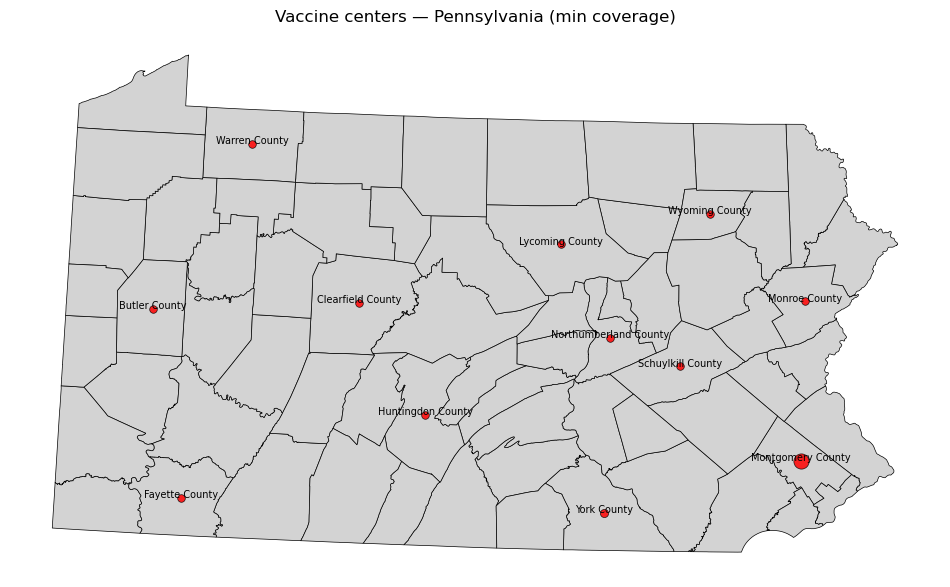

In [5]:
def plot_centers(state_shp, cdata, centers, title_suffix):
    """Base map for all counties; dots and labels only for vaccination center counties."""
    center_fips = sorted(set(centers) & set(cdata.keys()))
    fig, ax = plt.subplots(1, 1, figsize=(12, 10))
    state_shp.plot(ax=ax, color="lightgray", edgecolor="black", linewidth=0.5)
    state_name = next(iter(cdata.values()))["state"]
    densities = []
    for fips in center_fips:
        area = float(cdata[fips].get("area_sqmi") or 1.0)
        densities.append(cdata[fips]["population"] / max(area, 1e-6))
    dmax = max(densities) if densities else 1.0
    scale_factor = 120.0 / dmax
    for i, fips in enumerate(center_fips):
        sub = state_shp[state_shp["GEOID"] == fips]
        if sub.empty:
            continue
        pt = sub.geometry.centroid.iloc[0]
        size = max(densities[i] * scale_factor, 30.0)
        ax.scatter(
            pt.x,
            pt.y,
            s=size,
            c="red",
            alpha=0.85,
            edgecolors="black",
            linewidths=0.5,
        )
        ax.annotate(
            cdata[fips]["name"],
            (pt.x, pt.y),
            fontsize=7,
            ha="center",
        )
    ax.set_title(f"Vaccine centers — {state_name} ({title_suffix})")
    ax.axis("off")
    plt.show()


plot_centers(state_shp, cdata, set(centers_a), "min coverage")

In [6]:
rows = []
for fips in cdata:
    rows.append(
        {
            "FIPS": fips,
            "County": cdata[fips]["name"],
            "Population": cdata[fips]["population"],
            "Is_Center": fips in centers_a,
        }
    )
df_a = pd.DataFrame(rows)
display(df_a)

,FIPS,County,Population,Is_Center
0,42001,Adams County,107594,False
1,42003,Allegheny County,1225035,False
2,42005,Armstrong County,63698,False
3,42007,Beaver County,166032,False
4,42009,Bedford County,47480,False
5,42011,Berks County,440072,False
6,42013,Blair County,119541,False
7,42015,Bradford County,59600,False
8,42017,Bucks County,647828,False
9,42019,Butler County,200169,True


In [7]:
_buf = io.StringIO()
with contextlib.redirect_stdout(_buf):
    centers_b, obj_b, time_b, assigned = solve_equitable(adj, cdata, K)
print(
    f"Equitable (k={K}): {len(centers_b)} centers, objective {obj_b:.2f}, {time_b:.4f}s"
)

Equitable (k=30): 30 centers, objective 47525049.30, 0.0294s


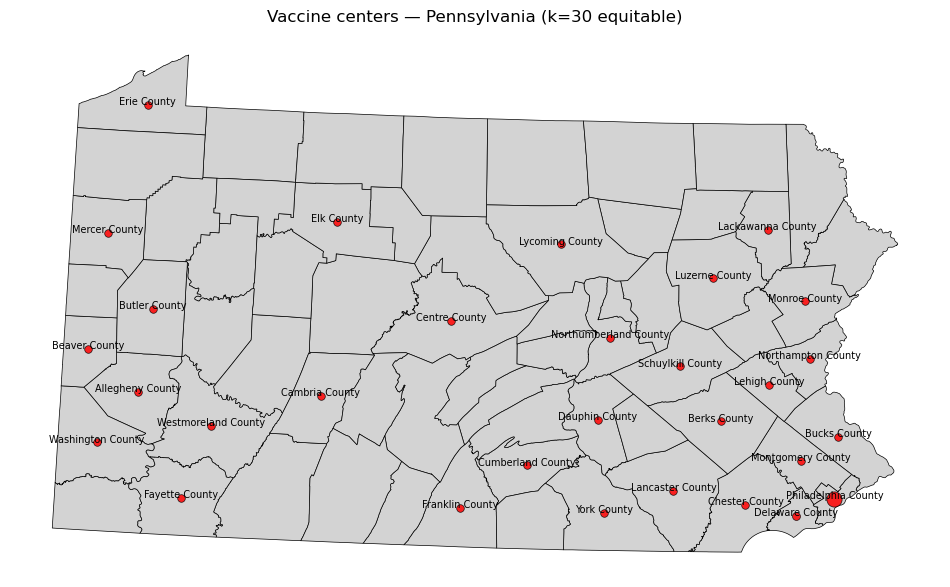

In [8]:
plot_centers(state_shp, cdata, set(centers_b), f"k={K} equitable")

In [9]:
rows = []
for fips in cdata:
    rows.append(
        {
            "FIPS": fips,
            "County": cdata[fips]["name"],
            "Population": cdata[fips]["population"],
            "Is_Center": fips in centers_b,
            "Assigned_To": assigned[fips],
        }
    )
df_b = pd.DataFrame(rows)
display(df_b)

,FIPS,County,Population,Is_Center,Assigned_To
0,42001,Adams County,107594,False,42041
1,42003,Allegheny County,1225035,True,42003
2,42005,Armstrong County,63698,False,42019
3,42007,Beaver County,166032,True,42007
4,42009,Bedford County,47480,False,42021
5,42011,Berks County,440072,True,42011
6,42013,Blair County,119541,False,42021
7,42015,Bradford County,59600,False,42081
8,42017,Bucks County,647828,True,42017
9,42019,Butler County,200169,True,42019
